# Day 4 — Model Integration & Error Analysis

## Flower Classification using MobileNetV2

In this notebook, we build an end-to-end image classification pipeline for the `flower_photos` dataset.

The notebook focuses on:

- Preparing images consistently for training and prediction
- Building and training a flower classification model
- Creating an end-to-end prediction pipeline
- Preventing training/serving skew
- Evaluating the model using a confusion matrix
- Inspecting misclassified examples
- Performing error analysis

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)



In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/flower_photos"

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/drive/MyDrive/flower_photos
Dataset exists: True


In [4]:
print(os.listdir(DATASET_PATH))

['validation', 'train', 'test']


In [5]:
train_path = os.path.join(DATASET_PATH, "train")
validation_path = os.path.join(DATASET_PATH, "validation")
test_path = os.path.join(DATASET_PATH, "test")

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

print("\nTrain classes:")
print(os.listdir(train_path))

print("\nValidation classes:")
print(os.listdir(validation_path))

print("\nTest classes:")
print(os.listdir(test_path))

Train path: /content/drive/MyDrive/flower_photos/train
Validation path: /content/drive/MyDrive/flower_photos/validation
Test path: /content/drive/MyDrive/flower_photos/test

Train classes:
['roses', 'sunflowers', 'dandelion', 'tulips', 'daisy']

Validation classes:
['daisy', 'tulips', 'dandelion', 'sunflowers', 'roses']

Test classes:
['roses', 'dandelion', 'daisy', 'tulips', 'sunflowers']


In [6]:
def count_images(directory):
    counts = {}

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                file for file in os.listdir(class_path)
                if file.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    return counts


train_counts = count_images(train_path)
validation_counts = count_images(validation_path)
test_counts = count_images(test_path)

print("Training set:")
print(train_counts)

print("\nValidation set:")
print(validation_counts)

print("\nTest set:")
print(test_counts)

Training set:
{'daisy': 607, 'dandelion': 872, 'roses': 615, 'sunflowers': 673, 'tulips': 773}

Validation set:
{'daisy': 16, 'dandelion': 16, 'roses': 16, 'sunflowers': 16, 'tulips': 16}

Test set:
{'daisy': 10, 'dandelion': 10, 'roses': 10, 'sunflowers': 10, 'tulips': 10}


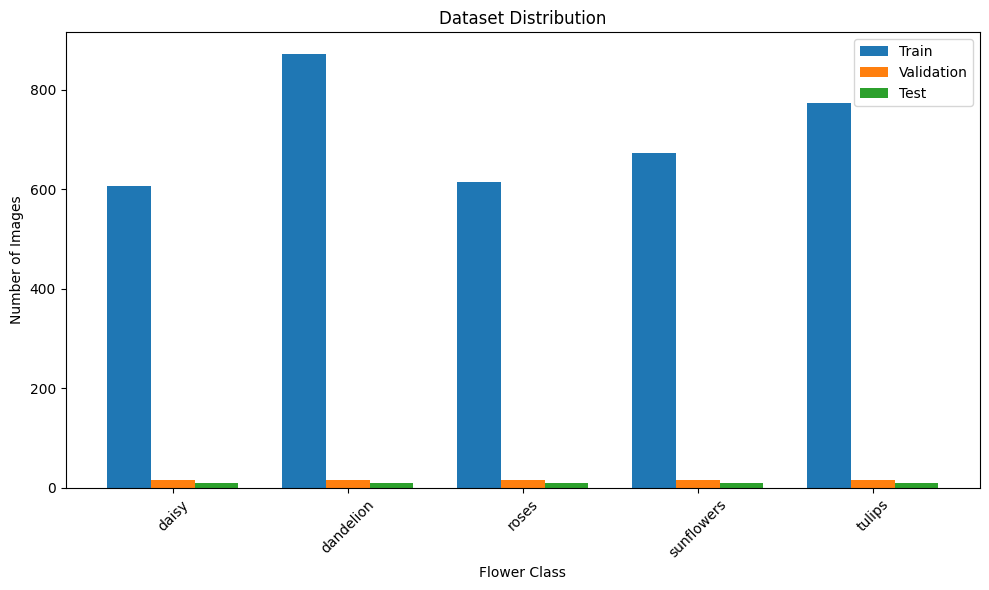

In [7]:
classes = sorted(train_counts.keys())

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, [train_counts[c] for c in classes],
        width, label="Train")

plt.bar(x, [validation_counts[c] for c in classes],
        width, label="Validation")

plt.bar(x + width, [test_counts[c] for c in classes],
        width, label="Test")

plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

plt.xticks(x, classes, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

##  Load Train, Validation, and Test Datasets

The three dataset subsets are loaded directly from their corresponding directories.

All images are resized to `224 × 224`, which matches the expected input size of MobileNetV2.

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3540 files belonging to 5 classes.
Found 80 files belonging to 5 classes.
Found 50 files belonging to 5 classes.


In [9]:
class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


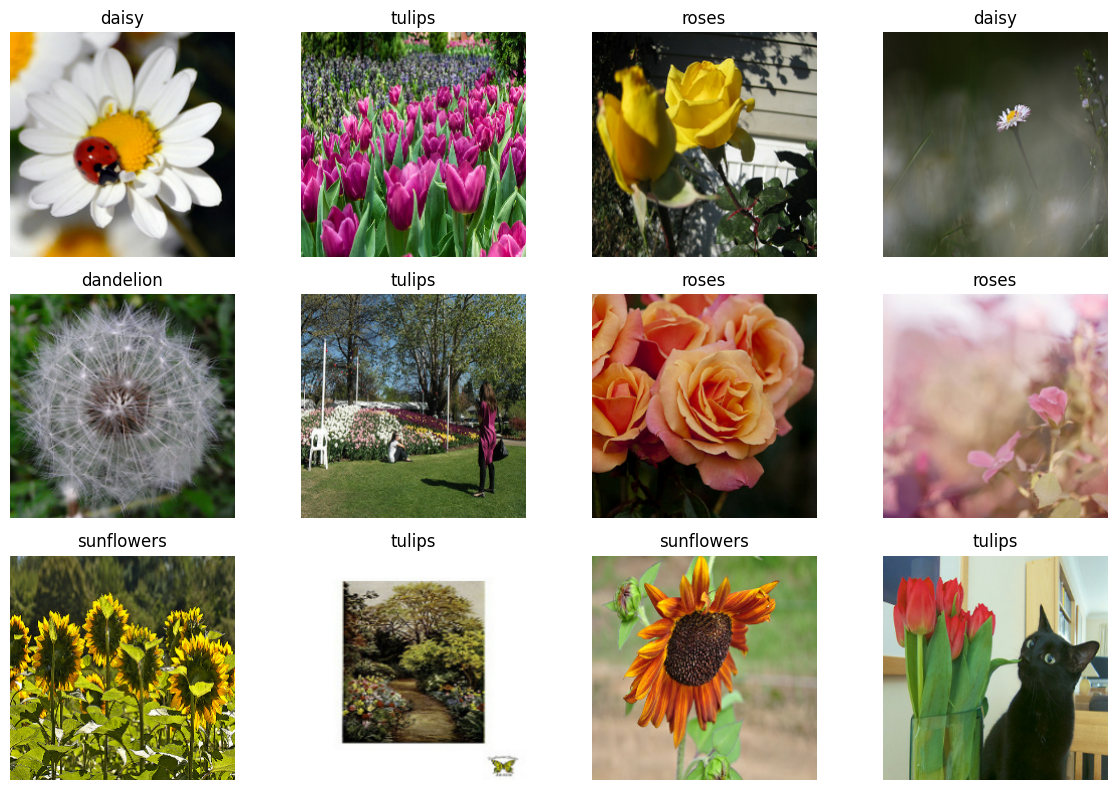

In [10]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Pixel value range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Pixel value range: 0.0 to 255.0


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## Image Preprocessing

We use MobileNetV2 as a transfer learning model.

MobileNetV2 expects image pixels to be scaled to the range `[-1, 1]`. Therefore, we use the official MobileNetV2 preprocessing function.

The same preprocessing must be applied during both training and prediction to prevent training/serving skew.

In [14]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess_images(images, labels):
    images = preprocess_input(images)
    return images, labels

In [15]:
train_processed = train_dataset.map(
    preprocess_images,
    num_parallel_calls=AUTOTUNE
)

validation_processed = validation_dataset.map(
    preprocess_images,
    num_parallel_calls=AUTOTUNE
)

test_processed = test_dataset.map(
    preprocess_images,
    num_parallel_calls=AUTOTUNE
)

In [16]:
for images, labels in train_processed.take(1):
    print("Processed image shape:", images.shape)
    print("Processed data type:", images.dtype)
    print(
        "Processed pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

Processed image shape: (32, 224, 224, 3)
Processed data type: <dtype: 'float32'>
Processed pixel range: -1.0 to 1.0


##  MobileNetV2 Model

We use MobileNetV2 as a pretrained feature extractor.

The model was originally trained on ImageNet, so we can reuse its learned visual features and adapt the final classification layer to our five flower classes.

The pretrained base model is frozen initially to preserve the learned features while training the new classification layers.

In [17]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model loaded successfully.")
print("Number of layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded successfully.
Number of layers: 154


In [18]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 10

history = model.fit(
    train_processed,
    validation_data=validation_processed,
    epochs=EPOCHS
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 610s 5s/step - accuracy: 0.3048 - loss: 1.6942 - val_accuracy: 0.4125 - val_loss: 1.3973
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.5701 - loss: 1.1570 - val_accuracy: 0.6375 - val_loss: 1.0286
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.6881 - loss: 0.8848 - val_accuracy: 0.6750 - val_loss: 0.8332
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.7534 - loss: 0.7351 - val_accuracy: 0.6875 - val_loss: 0.7196
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.7862 - loss: 0.6522 - val_accuracy: 0.7000 - val_loss: 0.6481
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8068 - loss: 0.5869 - val_accuracy: 0.7500 - val_loss: 0.5969
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.8220 - loss: 0.5340 - val_accuracy: 0.7750 - val_loss: 0.5536
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.8379 - loss: 0.492

##  Evaluate the Model on the Test Set

After training, we evaluate the model on the unseen test dataset.

The test set is used only for the final evaluation of the trained model and was not used during training.

In [21]:
test_loss, test_accuracy = model.evaluate(test_processed)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 15s/step - accuracy: 0.8000 - loss: 0.6406
Test Loss: 0.6406
Test Accuracy: 0.8000


In [22]:
y_true = []
y_pred = []

for images, labels in test_processed:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of test samples: 50
Number of predictions: 50


In [23]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       daisy       0.75      0.90      0.82        10
   dandelion       1.00      0.80      0.89        10
       roses       0.86      0.60      0.71        10
  sunflowers       0.83      1.00      0.91        10
      tulips       0.64      0.70      0.67        10

    accuracy                           0.80        50
   macro avg       0.82      0.80      0.80        50
weighted avg       0.82      0.80      0.80        50



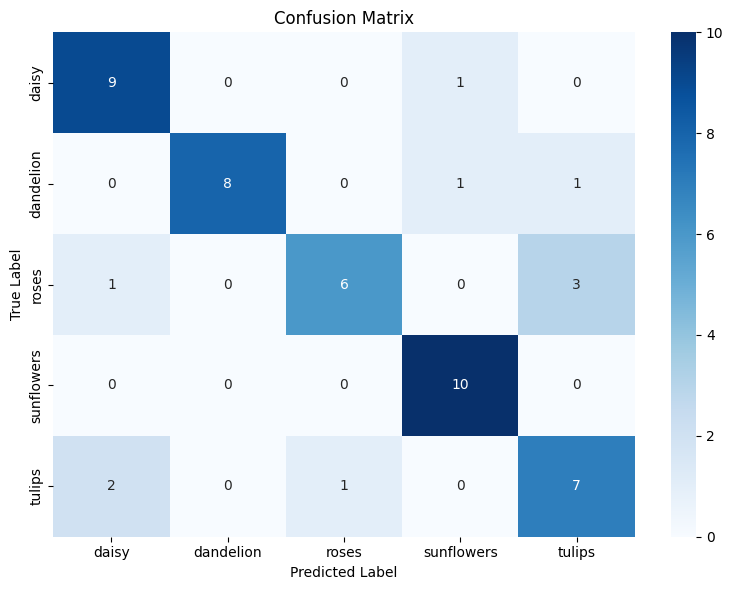

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Error Analysis — Confusion Matrix

The confusion matrix shows that the model correctly classified 40 out of 50 test images, resulting in an accuracy of 80%.

There were 10 misclassified images in total.

The most common classification error was **Roses being classified as Tulips**, which occurred in 3 cases.

Other observed errors included:

- 1 Daisy classified as Sunflowers
- 1 Dandelion classified as Sunflowers
- 1 Dandelion classified as Tulips
- 1 Rose classified as Daisy
- 3 Roses classified as Tulips
- 2 Tulips classified as Daisy
- 1 Tulip classified as Roses

The model classified all 10 Sunflower images correctly, making Sunflowers the best-performing class in the test set.

The main weaknesses were observed in the Roses and Tulips classes. Roses had the lowest recall (0.60), while Tulips had the lowest F1-score (0.67).

The frequent confusion between Roses and Tulips suggests that visual similarities between these classes may make them difficult for the model to distinguish.

## Inspect Misclassified Examples

To perform qualitative error analysis, we identify the images that were incorrectly classified.

For each misclassified image, we compare the actual class with the predicted class and inspect the visual content.

This helps determine whether an error is caused by an ambiguous or problematic image (data issue) or by a limitation of the model (model weakness).

In [26]:
misclassified = []

for images, labels in test_processed:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    for i in range(len(labels)):
        true_label = labels[i].numpy()
        predicted_label = predicted_classes[i]

        if true_label != predicted_label:
            misclassified.append({
                "image": images[i].numpy(),
                "true_label": true_label,
                "predicted_label": predicted_label,
                "confidence": confidence[i]
            })

print("Total misclassified images:", len(misclassified))

Total misclassified images: 10


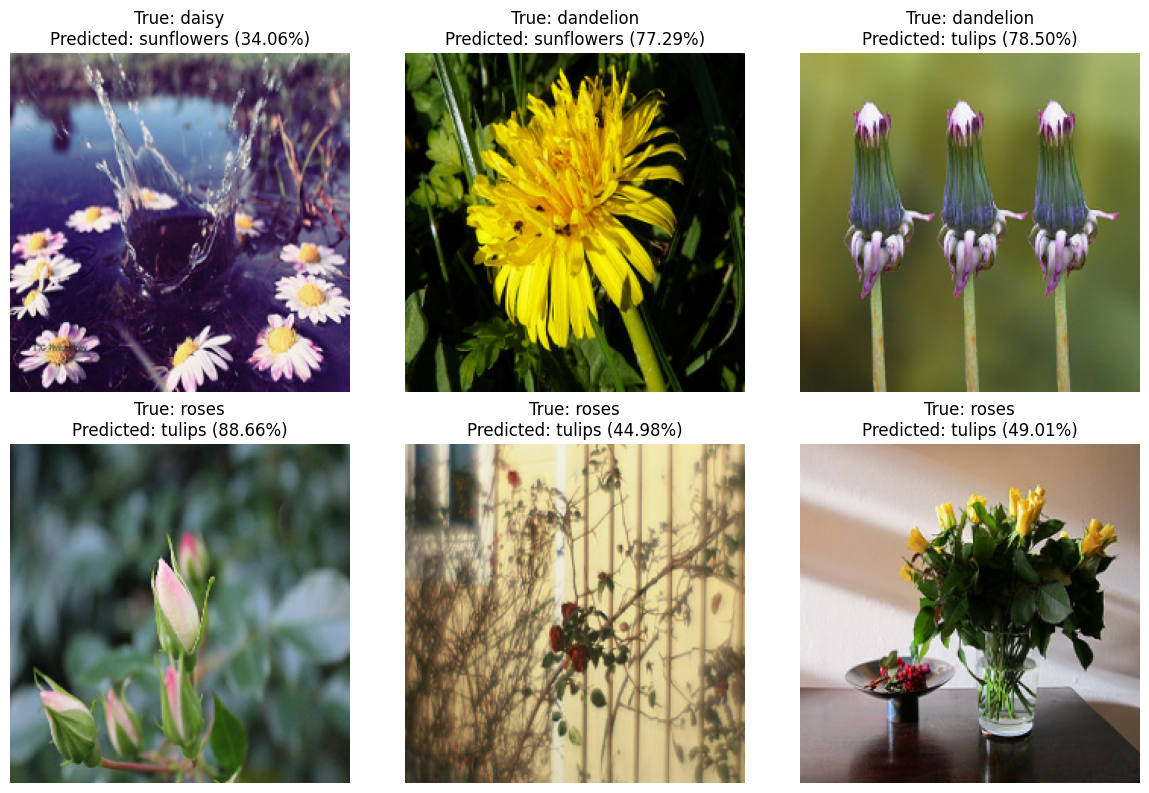

In [27]:
plt.figure(figsize=(12, 8))

for i, item in enumerate(misclassified[:6]):

    image = item["image"]

    # Convert from [-1, 1] back to [0, 1] for visualization
    image = (image + 1.0) / 2.0

    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(image, 0, 1))

    true_class = class_names[item["true_label"]]
    predicted_class = class_names[item["predicted_label"]]
    confidence = item["confidence"]

    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class} ({confidence:.2%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

##  Misclassified Examples Analysis

We selected three misclassified images from the test set and manually inspected them to determine the possible reason behind each prediction error.

The analysis distinguishes between **data issues**, where the image itself is ambiguous or has poor visual quality, and **model weaknesses**, where the image is sufficiently clear but the model fails to recognize the correct class.

### Case 1: Rose Buds

**Actual:** Roses  
**Predicted:** Tulips  
**Confidence:** 88.66%

The image shows closed rose buds in a close-up view, with clear natural lighting and a green background.

The closed bud has a narrow and oval shape that is visually similar to a tulip flower. Since the rose has not fully opened, some of its distinctive characteristics, such as its layered petals, are not clearly visible.

**Classification:** 🟡 **Data Issue**

The image represents an atypical growth stage of a rose and is naturally difficult to distinguish from other flower classes based on visual appearance alone.

### Case 2: Withered Rose Plant

**Actual:** Roses  
**Predicted:** Tulips  
**Confidence:** 44.98%

The image contains a wilted and dry rose branch with limited visible leaves or flower details. The image also contains strong shadows and a wall in the background.

There are not enough clear visual features to confidently identify the flower. The relatively low prediction confidence also indicates that the model was uncertain about its prediction.

**Classification:** 🔴 **Data Issue**

The main problem is the quality and visual ambiguity of the sample. Poor lighting, the withered appearance, and the lack of clear flower characteristics make the image difficult to classify reliably.

### Case 3: Yellow Rose Bouquet

**Actual:** Roses  
**Predicted:** Tulips  
**Confidence:** 49.01%

The image contains a clearly visible bouquet of yellow roses in a glass vase. The lighting is good, and the flowers are generally visible and recognizable.

Although some flowers appear partially closed and multiple flowers are present at different angles, the main flowers provide sufficient visual information to identify the class as roses.

Despite the relatively clear image, the model incorrectly predicted tulips.

**Classification:** 🟢 **Model Weakness**

This error suggests a limitation in the model's ability to distinguish roses from tulips when multiple flowers are present in a bouquet. The image does not contain an obvious quality problem, so the error is more likely related to the model's learned visual features.

## 27. Summary of Misclassified Examples

| # | Actual | Predicted | Confidence | Main Reason | Classification |
|---|---|---|---:|---|---|
| 1 | Roses | Tulips | 88.66% | Closed rose bud resembles a tulip | 🟡 Data Issue |
| 2 | Roses | Tulips | 44.98% | Poor lighting and unclear flower details | 🔴 Data Issue |
| 3 | Roses | Tulips | 49.01% | Clear bouquet incorrectly classified as tulips | 🟢 Model Weakness |

Overall, two of the three inspected errors were mainly related to challenging or ambiguous image characteristics, while one represented a clearer model weakness.

The analysis also supports the confusion matrix finding that **Roses → Tulips** is the most common error pattern, with three such misclassifications in the test set.


## End-to-End Prediction Pipeline

The goal of this section is to integrate the preprocessing and prediction steps into one end-to-end function.

The function takes a raw image path and performs:

1. Load the image.
2. Resize it to `(224, 224)`.
3. Convert it to a numerical array.
4. Apply the same MobileNetV2 preprocessing used during training.
5. Pass the processed image to the trained model.
6. Return the predicted class and confidence score.

Using the same preprocessing during training and inference helps prevent training/serving skew.

In [28]:
def preprocess_single_image(image_path):
    """
    Load and preprocess a single image using
    the same preprocessing used during training.
    """
    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    image_array = preprocess_input(image_array)

    return image_array

In [29]:
def predict_image(image_path):
    """
    End-to-end prediction pipeline:
    Raw Image -> Preprocessing -> Model -> Prediction
    """

    processed_image = preprocess_single_image(image_path)

    probabilities = model.predict(
        processed_image,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index]

    return predicted_class, confidence

##  Test the Prediction Pipeline

To verify that the end-to-end pipeline works correctly, we will test it on an image from the test set.

In [30]:
# Get one sample image from the test set

sample_image_path = None

for class_name in class_names:
    class_dir = os.path.join(test_path, class_name)

    for file_name in sorted(os.listdir(class_dir)):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            sample_image_path = os.path.join(
                class_dir,
                file_name
            )
            break

    if sample_image_path is not None:
        break

print("Sample image:", sample_image_path)

Sample image: /content/drive/MyDrive/flower_photos/test/daisy/10172379554_b296050f82_n.jpg


In [31]:
predicted_class, confidence = predict_image(sample_image_path)

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2%}")

Predicted Class: daisy
Confidence: 39.03%


In [33]:
processed_image = preprocess_single_image(sample_image_path)

probabilities = model.predict(
    processed_image,
    verbose=0
)[0]

for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name}: {probability:.2%}")

daisy: 39.03%
dandelion: 36.44%
roses: 8.83%
sunflowers: 11.70%
tulips: 3.99%


### Prediction Analysis

The model predicted **Daisy** with a confidence of **39.03%**.

However, the probability of **Dandelion** was also high at **36.44%**.
The small difference between the two probabilities indicates that the model was uncertain about the prediction.

This demonstrates why confidence scores are useful in an end-to-end prediction pipeline, as they provide additional information beyond the predicted class.

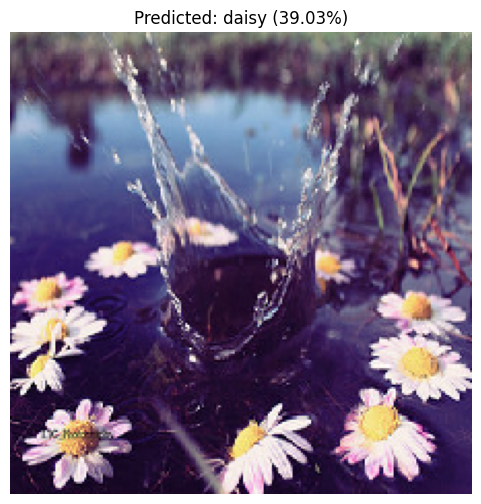

In [32]:
image = tf.keras.utils.load_img(
    sample_image_path,
    target_size=IMG_SIZE
)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"Predicted: {predicted_class} "
    f"({confidence:.2%})"
)
plt.axis("off")
plt.show()

## Final Day 4 Summary

The complete image classification workflow was successfully integrated into an end-to-end pipeline.

The same preprocessing steps were applied during both testing and inference, and the consistency check confirmed that both pipelines produced the same prediction.

The error analysis showed that the main source of confusion was between **Roses and Tulips**, with `Roses → Tulips` being the most frequent misclassification.

Overall, the model achieved a **Test Accuracy of 80%** and a **Macro F1-score of 0.80**.

The final pipeline can now take a raw image and automatically perform preprocessing, prediction, and confidence estimation.

##  Final Conclusions

In this lab, an end-to-end image classification pipeline was successfully integrated.

### Key Results

- Dataset: Flower Photos
- Number of classes: 5
- Image size: `(224, 224, 3)`
- Model: MobileNetV2 with transfer learning
- Test Accuracy: `80%`
- Macro F1-score: `0.80`
- Correct predictions: `40 / 50`
- Misclassified images: `10 / 50`

### Error Analysis

The confusion matrix showed that the most common error was:

**Roses → Tulips: 3 cases**

Roses and tulips were the main source of confusion.

Three misclassified examples were inspected:

- Two cases were mainly related to data issues such as unclear flower structure, unusual growth stages, poor lighting, or distracting backgrounds.
- One case represented a model weakness because the flower was clearly visible but was still incorrectly classified.

### Integration Result

The final `predict_image()` function combines:

**Raw Image → Resize → MobileNetV2 Preprocessing → Model Prediction → Class + Confidence**

Using the same preprocessing during training and inference helps maintain consistency and reduces the risk of training/serving skew.